In [1]:
!pip install -q sentence-transformers rank_bm25 torch pandas numpy tqdm matplotlib seaborn

the number of corpus chunks: 341 | testing queries: 30


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Calculating scores: 100%|██████████| 30/30 [00:00<00:00, 148.73it/s]


Search Combination (E5-Large)  Acc@1 (%)  Acc@3 (%)  Acc@5 (%)  P@3 (%)  P@5 (%)  F1@3 (%)  F1@5 (%)   MRR  NDCG@3   MAP
                   Dense Only      66.67      83.33      90.00    27.78    18.00     41.67     30.00 0.754   0.790 0.754
                  Sparse Only      23.33      36.67      43.33    12.22     8.67     18.33     14.44 0.304   0.336 0.304
      Hybrid (Sparse + Dense)      36.67      53.33      63.33    17.78    12.67     26.67     21.11 0.469   0.511 0.469


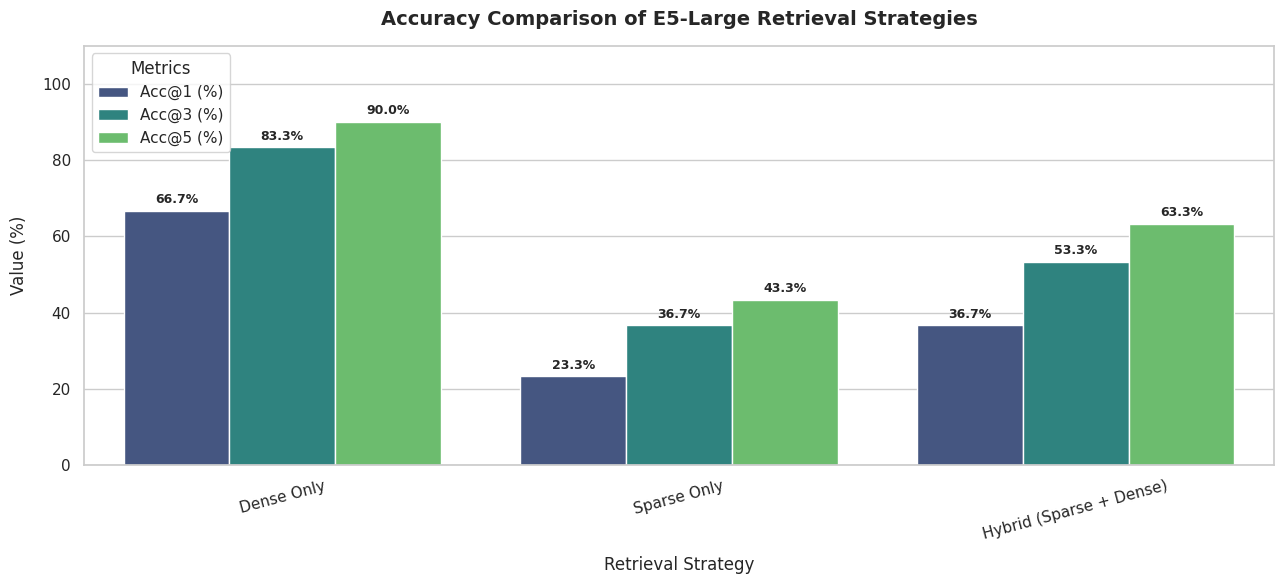

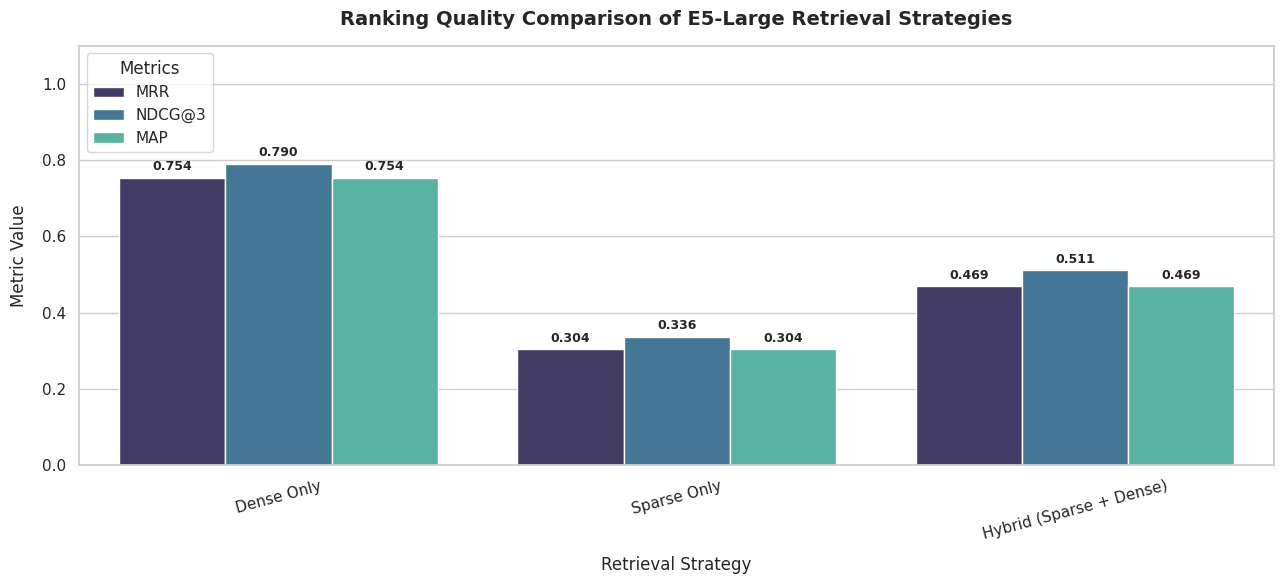

In [3]:
import json
import os
import gc
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = "/content/parsed_pdf.json"
DATASET_PATH = "/content/test_dataset.json"

def load_data():
    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError(f"file {DATA_PATH} is not found")
    with open(DATA_PATH, "r", encoding="utf-8") as f:
        return json.load(f)

def load_test_dataset():
    if not os.path.exists(DATASET_PATH):
        raise FileNotFoundError(f"test dataset {DATASET_PATH} is not found")
    with open(DATASET_PATH, "r", encoding="utf-8") as f:
        return json.load(f)

def calculate_ndcg(rank):
    if rank == 1: return 1.0
    elif 2 <= rank <= 5: return 1.0 / np.log2(rank + 1)
    return 0.0

def min_max_normalize(scores):
    s_min, s_max = np.min(scores), np.max(scores)
    if s_max == s_min:
        return np.zeros_like(scores, dtype=np.float32)
    return (scores - s_min) / (s_max - s_min)

def plot_benchmark_results(df):
    sns.set_theme(style="whitegrid")
    output_dir = "/content/e5_plots"
    os.makedirs(output_dir, exist_ok=True)

    metrics_quality = ["Acc@1 (%)", "Acc@3 (%)", "Acc@5 (%)"]
    df_melted = df.melt(id_vars="Search Combination (E5-Large)", value_vars=metrics_quality, var_name="Metric", value_name="Value")

    plt.figure(figsize=(13, 6))
    ax1 = sns.barplot(x="Search Combination (E5-Large)", y="Value", hue="Metric", data=df_melted, palette="viridis")
    plt.title("Accuracy Comparison of E5-Large Retrieval Strategies", pad=15, weight='bold', fontsize=14)
    plt.xlabel("Retrieval Strategy", labelpad=10, fontsize=12)
    plt.ylabel("Value (%)", labelpad=10, fontsize=12)
    plt.ylim(0, 110)
    plt.xticks(rotation=15)
    plt.legend(title="Metrics", loc="upper left")
    for p in ax1.patches:
        if p.get_height() > 0:
            ax1.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, weight='semibold')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/accuracy_comparison.png", dpi=300)
    plt.show()

    metrics_ranking = ["MRR", "NDCG@3", "MAP"]
    df_melted_rank = df.melt(id_vars="Search Combination (E5-Large)", value_vars=metrics_ranking, var_name="Metric", value_name="Value")

    plt.figure(figsize=(13, 6))
    ax2 = sns.barplot(x="Search Combination (E5-Large)", y="Value", hue="Metric", data=df_melted_rank, palette="mako")
    plt.title("Ranking Quality Comparison of E5-Large Retrieval Strategies", pad=15, weight='bold', fontsize=14)
    plt.xlabel("Retrieval Strategy", labelpad=10, fontsize=12)
    plt.ylabel("Metric Value", labelpad=10, fontsize=12)
    plt.ylim(0, 1.1)
    plt.xticks(rotation=15)
    plt.legend(title="Metrics", loc="upper left")
    for p in ax2.patches:
        if p.get_height() > 0:
            ax2.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, weight='semibold')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/ranking_comparison.png", dpi=300)
    plt.show()

def main():
    chunks = load_data()
    queries = load_test_dataset()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"the number of corpus chunks: {len(chunks)} | testing queries: {len(queries)}")

    model = SentenceTransformer('intfloat/multilingual-e5-large', device=device)

    corpus_texts_e5 = []
    corpus_tokenized = []
    for c in chunks:
        text = str(c['text'] if isinstance(c, dict) else c).strip()
        corpus_texts_e5.append(f"passage: {text}")
        corpus_tokenized.append(text.lower().split())

    dense_embeddings = model.encode(
        corpus_texts_e5,
        batch_size=32,
        show_progress_bar=True,
        convert_to_tensor=True,
        normalize_embeddings=True
    )
    bm25 = BM25Okapi(corpus_tokenized)

    strategies = ["Dense Only", "Sparse Only", "Hybrid (Sparse + Dense)"]
    results = {
        strat: {
            "acc_1": [], "acc_3": [], "acc_5": [],
            "p_3": [], "p_5": [], "f1_3": [], "f1_5": [],
            "mrr": [], "ndcg": [], "map": []
        } for strat in strategies
    }

    query_texts_e5 = [f"query: {q['query']}" for q in queries]
    query_embeddings = model.encode(
        query_texts_e5,
        batch_size=32,
        convert_to_tensor=True,
        normalize_embeddings=True
    )

    for idx, q_item in enumerate(tqdm(queries, desc="Calculating scores")):
        gt = q_item['target'].strip()
        q_text = q_item['query']

        q_dense = query_embeddings[idx]
        dense_scores_raw = torch.matmul(dense_embeddings, q_dense).cpu().numpy()

        q_tokenized = q_text.lower().split()
        sparse_scores_raw = bm25.get_scores(q_tokenized)

        dense_norm = min_max_normalize(dense_scores_raw)
        sparse_norm = min_max_normalize(sparse_scores_raw)
        hybrid_norm = 0.5 * sparse_norm + 0.5 * dense_norm

        strat_maps = {
            "Dense Only": dense_norm,
            "Sparse Only": sparse_norm,
            "Hybrid (Sparse + Dense)": hybrid_norm
        }

        for strat in strategies:
            scores = strat_maps[strat]
            top_5_idx = np.argsort(-scores)[:5]
            top_5_texts = [str(chunks[i]['text'] if isinstance(chunks[i], dict) else chunks[i]).strip() for i in top_5_idx]

            rank = -1
            for r_idx, text in enumerate(top_5_texts):
                if text == gt or gt in text or text in gt:
                    rank = r_idx + 1
                    break

            results[strat]["acc_1"].append(1.0 if rank == 1 else 0.0)

            if 1 <= rank <= 5:
                results[strat]["mrr"].append(1.0 / rank)
                results[strat]["ndcg"].append(calculate_ndcg(rank))
                results[strat]["map"].append(1.0 / rank)
            else:
                results[strat]["mrr"].append(0.0)
                results[strat]["ndcg"].append(0.0)
                results[strat]["map"].append(0.0)

            for k in [3, 5]:
                slice_texts = top_5_texts[:k]
                is_found = any(text == gt or gt in text or text in gt for text in slice_texts)

                acc_val = 1.0 if is_found else 0.0
                rec_val = 1.0 if is_found else 0.0
                prec_val = (1.0 / k) if is_found else 0.0
                f1_val = (2 * prec_val * rec_val) / (prec_val + rec_val) if is_found else 0.0

                results[strat][f"acc_{k}"].append(acc_val)
                results[strat][f"p_{k}"].append(prec_val)
                results[strat][f"f1_{k}"].append(f1_val)

    summary_data = []
    for strat in strategies:
        summary_data.append({
            "Search Combination (E5-Large)": strat,
            "Acc@1 (%)": round(np.mean(results[strat]["acc_1"]) * 100, 2),
            "Acc@3 (%)": round(np.mean(results[strat]["acc_3"]) * 100, 2),
            "Acc@5 (%)": round(np.mean(results[strat]["acc_5"]) * 100, 2),
            "P@3 (%)": round(np.mean(results[strat]["p_3"]) * 100, 2),
            "P@5 (%)": round(np.mean(results[strat]["p_5"]) * 100, 2),
            "F1@3 (%)": round(np.mean(results[strat]["f1_3"]) * 100, 2),
            "F1@5 (%)": round(np.mean(results[strat]["f1_5"]) * 100, 2),
            "MRR": round(np.mean(results[strat]["mrr"]), 3),
            "NDCG@3": round(np.mean(results[strat]["ndcg"]), 3),
            "MAP": round(np.mean(results[strat]["map"]), 3)
        })

    df = pd.DataFrame(summary_data)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print(df.to_string(index=False))

    plot_benchmark_results(df)

    del dense_embeddings, query_embeddings, model
    if device == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

if __name__ == "__main__":
    main()